In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
import seaborn as sns

In [2]:
# Load features

features_df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\features_rr.csv")

# Drop same weak features as LGBM
features_to_drop = ['kurtosis', 'mean', 'std', 'rms']
features_df = features_df.drop(columns=features_to_drop)

X = features_df.drop("RR", axis=1).values
y = features_df["RR"].values

# Rebuild subject IDs
num_subjects = 53
windows_per_subject = X.shape[0] // num_subjects
subjects = np.repeat(np.arange(num_subjects), windows_per_subject)
remaining = X.shape[0] - subjects.shape[0]
subjects = np.concatenate([subjects, np.arange(remaining)])

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Subjects shape:", subjects.shape)

Features shape: (1638, 8)
Labels shape: (1638,)
Subjects shape: (1638,)


In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

gkf = GroupKFold(n_splits=5)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=gkf.split(X, y, groups=subjects),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 600}
Best CV MAE: 2.1200036279360663


In [4]:
best_pipeline = grid.best_estimator_

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)
    print(f"Fold {fold+1} MAE: {mae:.3f} bpm")

print("\nMean MAE:", np.mean(mae_scores))
print("Std MAE:", np.std(mae_scores))

Fold 1 MAE: 2.596 bpm
Fold 2 MAE: 2.297 bpm
Fold 3 MAE: 1.681 bpm
Fold 4 MAE: 1.979 bpm
Fold 5 MAE: 2.047 bpm

Mean MAE: 2.1200036279360663
Std MAE: 0.30852208245620394


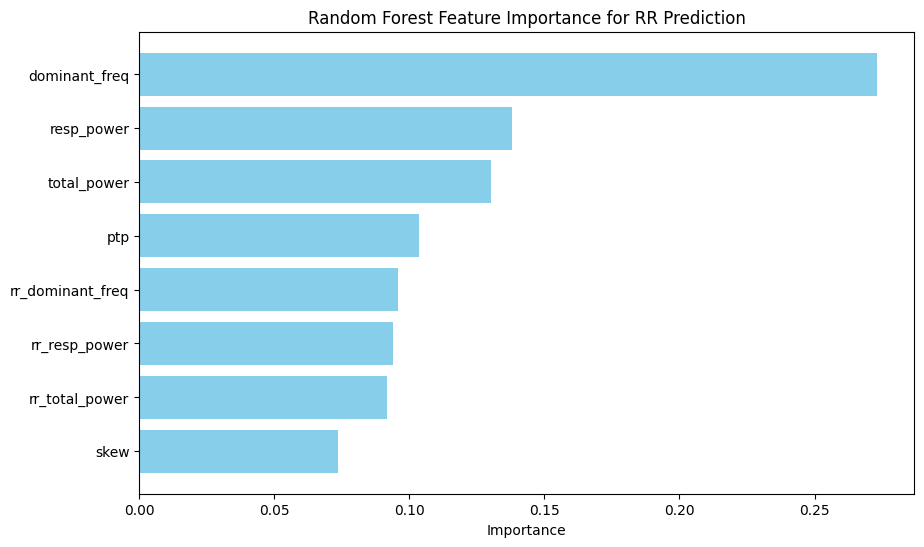

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Access the model inside the pipeline
rf_model = best_rf.named_steps['model']

# Feature names
feature_names = features_df.drop("RR", axis=1).columns

# Create feature importance dataframe
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance for RR Prediction")
plt.show()

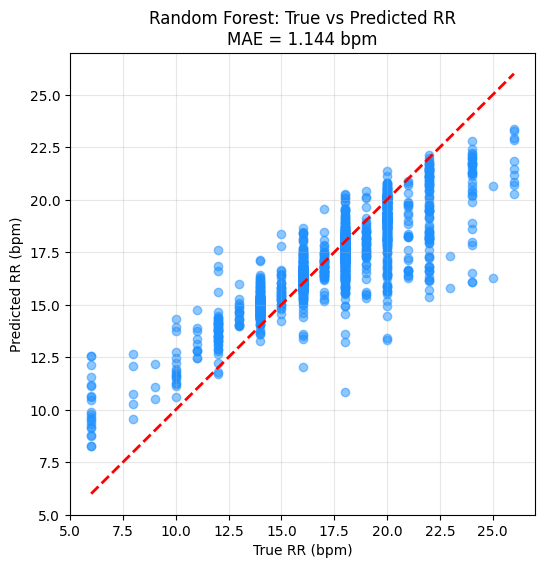

In [8]:
# Predict on full data
y_pred_full = best_rf.predict(X)
mae_full = mean_absolute_error(y, y_pred_full)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_full, alpha=0.5, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("True RR (bpm)")
plt.ylabel("Predicted RR (bpm)")
plt.title(f"Random Forest: True vs Predicted RR\nMAE = {mae_full:.3f} bpm")
plt.grid(alpha=0.3)
plt.show()

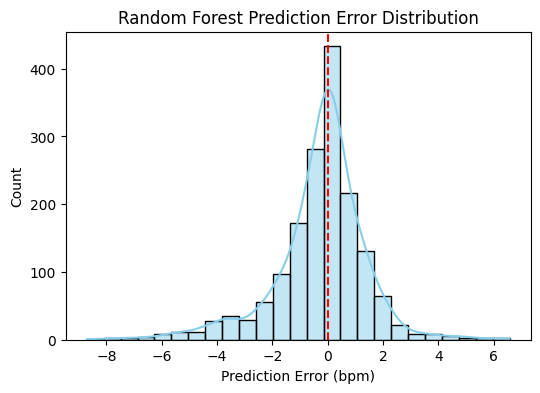

In [11]:
errors = y_pred_full - y
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=25, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error (bpm)")
plt.title("Random Forest Prediction Error Distribution")
plt.show()

In [5]:
import os
import joblib

# ---------------------------
# Saving the trained pipeline
# ---------------------------

model_folder = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models"

if not os.path.exists(model_folder):
    os.makedirs(model_folder)
    print(f"Folder created: {model_folder}")
else:
    print(f"Folder already exists: {model_folder}")

model_path = os.path.join(model_folder, "best_RF1_rr_pipeline.pkl")
joblib.dump(best_pipeline, model_path)

print(f"Model saved successfully at: {model_path}")

Folder already exists: C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models
Model saved successfully at: C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models\best_RF1_rr_pipeline.pkl
